<div style='border: 5px solid black; padding: 20px; border-radius: 6px;'>

## **Course:** DSC640 - Data Presentation and Visualization
## **Name:** Tim Hollis
## **Assignment:** Term Project Milestone 1
## **Date:** June 11, 2026

---

**Reference**

U.S. Department of Labor, Women's Bureau. (2024). *National database of childcare prices* [Data set]. https://www.dol.gov/agencies/wb/topics/featured-childcare

</div>

### **Initial Setup**

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display formatting - no scientific notation, comma-formatted numbers
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)

# Visualization formatting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Colorblind-safe project palette
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
PROJECT_PALETTE = [ROYAL_BLUE, PURPLE, FOREST_GREEN, AMBER]

# Loading dataset
childcare_df = pd.read_excel('nationaldatabaseofchildcareprices.xlsx')

print(f'✅ Setup complete - all libraries loaded and formatting applied')
print(f'📊 Dataset loaded: {childcare_df.shape[0]:,} rows × {childcare_df.shape[1]:,} columns')

✅ Setup complete - all libraries loaded and formatting applied
📊 Dataset loaded: 34,567 rows × 227 columns


### **Dataset Overview**

Before identifying a story, the structure of the dataset needs to be understood. The cell below confirms the unit of analysis (county-year), the time span covered, and organizes the 227 columns into logical groups so the relevant fields for this project can be isolated.

In [8]:
# Confirm the unit of analysis and coverage
print(f'🗓️ Study years: {childcare_df["StudyYear"].min()} to {childcare_df["StudyYear"].max()}')
state_count = childcare_df['State_Name'].nunique()
print(f'🏛️ Geographic coverage: {state_count} jurisdictions (50 states plus the District of Columbia)')
print(f'📍 County groups covered: {childcare_df.groupby(["State_Name", "County_Name"]).ngroups:,}')

# Summarize the column structure 
imputed_flags = [col for col in childcare_df.columns if col.startswith('i')]
percentile_cols = [col for col in childcare_df.columns if col.startswith('_75')]
price_cols = [col for col in childcare_df.columns if col.startswith(('MC', 'MFCC'))]

print(f'\n📋 Column structure (227 total):')
print(f'   Childcare price fields (center-based MC*, home-based MFCC*): {len(price_cols)}')
print(f'   75th percentile price variants (_75*): {len(percentile_cols)}')
print(f'   Imputation indicator flags (i*): {len(imputed_flags)}')
print(f'   Remaining: identifiers, labor force, earnings, and demographic fields')

# Highlighting critical fields for presentation
story_fields = ['MCInfant', 'MCToddler', 'MCPreschool', 'MHI', 'FME', 'FLFPR_20to64_Under6']
print(f'\n🎯 Key story fields confirmed present: {", ".join(story_fields)}')

🗓️ Study years: 2008 to 2018
🏛️ Geographic coverage: 51 jurisdictions (50 states plus the District of Columbia)
📍 County groups covered: 3,144

📋 Column structure (227 total):
   Childcare price fields (center-based MC*, home-based MFCC*): 34
   75th percentile price variants (_75*): 34
   Imputation indicator flags (i*): 99
   Remaining: identifiers, labor force, earnings, and demographic fields

🎯 Key story fields confirmed present: MCInfant, MCToddler, MCPreschool, MHI, FME, FLFPR_20to64_Under6


### **Working Dataset**

Only a fraction of the 227 columns are needed for this story. The cell below selects the identifier, price, income, and labor force fields, renames them into readable form, and checks completeness so we know how much of the country the analysis can actually speak for.

In [3]:
# Select the fields that support the affordability and labor force story
working_columns = {
    'State_Name': 'state',
    'State_Abbreviation': 'state_abbr',
    'County_Name': 'county',
    'County_FIPS_Code': 'fips',
    'StudyYear': 'year',
    'MCInfant': 'center_infant_weekly',
    'MCToddler': 'center_toddler_weekly',
    'MCPreschool': 'center_preschool_weekly',
    'MFCCInfant': 'home_infant_weekly',
    'MHI_2018': 'median_household_income',
    'FME_2018': 'female_median_earnings',
    'FLFPR_20to64': 'female_lfp_rate',
    'FLFPR_20to64_Under6': 'female_lfp_rate_under6',
    'MLFPR_20to64': 'male_lfp_rate',
    'UNR_20to64': 'unemployment_rate',
    'PR_F': 'family_poverty_rate',
    'TotalPop': 'total_population',
    'Households': 'households'
}

story_df = childcare_df[list(working_columns.keys())].rename(columns=working_columns)

print(f'✅ Working dataset created: {story_df.shape[0]:,} rows × {story_df.shape[1]} columns')

# Check the key story fields for missing values
print(f'\n🔍 Missing values by column:')
missing = story_df.isnull().sum()
for col, count in missing[missing > 0].sort_values(ascending=False).items():
    print(f'   {col}: {count:,} missing ({count / len(story_df) * 100:.1f}%)')
if missing.sum() == 0:
    print('   No missing values found')

# Sanity-check the price fields - these should be weekly dollar amounts
print(f'\n💵 Median weekly infant care price (center-based), all county-years: ${story_df["center_infant_weekly"].median():,.2f}')
print(f'💵 Median household income (2018 dollars), all county-years: ${story_df["median_household_income"].median():,.2f}')

✅ Working dataset created: 34,567 rows × 18 columns

🔍 Missing values by column:
   home_infant_weekly: 11,184 missing (32.4%)
   center_infant_weekly: 10,974 missing (31.7%)
   center_toddler_weekly: 10,974 missing (31.7%)
   center_preschool_weekly: 10,974 missing (31.7%)

💵 Median weekly infant care price (center-based), all county-years: $134.50
💵 Median household income (2018 dollars), all county-years: $48,505.60


### **Finding 1: The Affordability Gap**

The U.S. Department of Health and Human Services defines childcare as affordable when it costs no more than 7% of household income. The cell below converts weekly center-based infant prices to annual cost, measures them against each county's median household income, and tracks how that burden moved between 2008 and 2018.

In [4]:
# Build the analysis frame with only county-years with observed infant prices
afford_df = story_df.dropna(subset=['center_infant_weekly', 'median_household_income']).copy()
afford_df['annual_infant_cost'] = afford_df['center_infant_weekly'] * 52
afford_df['income_share'] = afford_df['annual_infant_cost'] / afford_df['median_household_income'] * 100

print(f'✅ Analysis frame: {len(afford_df):,} county-years with observed prices')

# Check whether price reporting is stable across years
print(f'\n📅 County-years with price data by study year:')
year_counts = afford_df['year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f'   {year}: {count:,}')

# Calculating infant care as a share of median household income
print(f'\n💰 Annual center-based infant care cost (median): ${afford_df["annual_infant_cost"].median():,.0f}')
print(f'📊 Median share of household income: {afford_df["income_share"].median():.1f}%')
print(f'🚨 County-years exceeding the 7% HHS affordability benchmark: {(afford_df["income_share"] > 7).mean() * 100:.1f}%')

# Changes over the decade
for year in [2008, 2018]:
    subset = afford_df[afford_df['year'] == year]
    print(f'\n🗓️ {year}: median annual cost ${subset["annual_infant_cost"].median():,.0f} '
          f'| median income share {subset["income_share"].median():.1f}% '
          f'| counties above 7%: {(subset["income_share"] > 7).mean() * 100:.1f}%')

✅ Analysis frame: 23,593 county-years with observed prices

📅 County-years with price data by study year:
   2008: 1,424
   2009: 1,901
   2010: 1,991
   2011: 1,992
   2012: 2,053
   2013: 2,074
   2014: 2,323
   2015: 2,398
   2016: 2,641
   2017: 2,436
   2018: 2,360

💰 Annual center-based infant care cost (median): $6,994
📊 Median share of household income: 14.7%
🚨 County-years exceeding the 7% HHS affordability benchmark: 99.7%

🗓️ 2008: median annual cost $6,273 | median income share 13.4% | counties above 7%: 99.6%

🗓️ 2018: median annual cost $7,987 | median income share 16.1% | counties above 7%: 99.8%


### **Finding 2: Where Care Costs More, Fewer Mothers Work**

The dataset contains both the price of care and the labor force participation rate of women with children under 6 in the same county. The cell below corrects the affordability share to use nominal income, then tests whether counties with a heavier care burden show lower workforce participation among mothers of young children.

In [5]:
# Recalculate income share using nominal MHI to match nominal prices
afford_df = afford_df.merge(
    childcare_df[['County_FIPS_Code', 'StudyYear', 'MHI']].rename(
        columns={'County_FIPS_Code': 'fips', 'StudyYear': 'year', 'MHI': 'nominal_income'}),
    on=['fips', 'year'], how='left'
)
afford_df['income_share'] = afford_df['annual_infant_cost'] / afford_df['nominal_income'] * 100

for year in [2008, 2018]:
    subset = afford_df[afford_df['year'] == year]
    print(f'🗓️ {year} (corrected): median income share {subset["income_share"].median():.1f}% '
          f'| counties above 7%: {(subset["income_share"] > 7).mean() * 100:.1f}%')

# 2018 correlation between care burden and maternal workforce participation
snapshot = afford_df[afford_df['year'] == 2018].dropna(subset=['income_share', 'female_lfp_rate_under6'])
corr = snapshot['income_share'].corr(snapshot['female_lfp_rate_under6'])
print(f'\n🔗 Correlation (income share vs. LFP of mothers with kids under 6, 2018): {corr:.3f}')

# Compare participation across affordability quartiles
snapshot['burden_quartile'] = pd.qcut(snapshot['income_share'], 4,
                                      labels=['Least burdened', 'Q2', 'Q3', 'Most burdened'])
print(f'\n📊 Median LFP of mothers with children under 6, by care-burden quartile (2018):')
for quartile, group in snapshot.groupby('burden_quartile', observed=True):
    print(f'   {quartile}: {group["female_lfp_rate_under6"].median():.1f}% '
          f'(n = {len(group):,} counties)')

🗓️ 2008 (corrected): median income share 15.4% | counties above 7%: 100.0%
🗓️ 2018 (corrected): median income share 16.1% | counties above 7%: 99.8%

🔗 Correlation (income share vs. LFP of mothers with kids under 6, 2018): -0.044

📊 Median LFP of mothers with children under 6, by care-burden quartile (2018):
   Least burdened: 72.2% (n = 590 counties)
   Q2: 71.8% (n = 590 counties)
   Q3: 72.2% (n = 590 counties)
   Most burdened: 72.0% (n = 590 counties)


### **Finding 2 (Revised): The Second-Earner Math**

County-level participation rates show no simple relationship with care prices, so the story shifts to the household level: what share of a mother's median earnings does childcare consume? The cell below prices a one-infant household and a two-child (infant plus preschooler) household against female median earnings in 2018.

In [6]:
# Merge nominal female median earnings to match nominal prices
earnings_df = afford_df.merge(
    childcare_df[['County_FIPS_Code', 'StudyYear', 'FME']].rename(
        columns={'County_FIPS_Code': 'fips', 'StudyYear': 'year', 'FME': 'female_earnings_nominal'}),
    on=['fips', 'year'], how='left'
)

# 2018 comparison infant vs. infant plus preschooler
snapshot = earnings_df[earnings_df['year'] == 2018].dropna(
    subset=['annual_infant_cost', 'center_preschool_weekly', 'female_earnings_nominal']).copy()
snapshot['annual_preschool_cost'] = snapshot['center_preschool_weekly'] * 52
snapshot['one_child_share'] = snapshot['annual_infant_cost'] / snapshot['female_earnings_nominal'] * 100
snapshot['two_child_share'] = ((snapshot['annual_infant_cost'] + snapshot['annual_preschool_cost'])
                               / snapshot['female_earnings_nominal'] * 100)

print(f'✅ 2018 counties in scope: {len(snapshot):,}')
print(f'\n👶 One infant in center care, share of female median earnings:')
print(f'   Median county: {snapshot["one_child_share"].median():.1f}%')
print(f'   Toughest quarter of counties: {snapshot["one_child_share"].quantile(0.75):.1f}% or more')
print(f'\n👶👧 Infant + preschooler in center care, share of female median earnings:')
print(f'   Median county: {snapshot["two_child_share"].median():.1f}%')
print(f'   Counties where two kids cost over a third of her earnings: '
      f'{(snapshot["two_child_share"] > 33.3).mean() * 100:.1f}%')

# Texas spotlight for audience relevance
texas = snapshot[snapshot['state_abbr'] == 'TX']
bexar = texas[texas['county'] == 'Bexar County']
print(f'\n🤠 Texas (2018): {len(texas):,} counties reporting')
print(f'   Median one-child share of female earnings: {texas["one_child_share"].median():.1f}%')
if len(bexar) > 0:
    print(f'   Bexar County: infant care ${bexar["annual_infant_cost"].iloc[0]:,.0f}/year, '
          f'{bexar["one_child_share"].iloc[0]:.1f}% of female median earnings')

✅ 2018 counties in scope: 2,360

👶 One infant in center care, share of female median earnings:
   Median county: 33.2%
   Toughest quarter of counties: 39.4% or more

👶👧 Infant + preschooler in center care, share of female median earnings:
   Median county: 61.1%
   Counties where two kids cost over a third of her earnings: 97.3%

🤠 Texas (2018): 254 counties reporting
   Median one-child share of female earnings: 31.7%
   Bexar County: infant care $8,666/year, 33.1% of female median earnings


### **Visualizing the Story**

Two views anchor the narrative: how the care burden moved over the decade against the federal benchmark, and how the 2018 distribution of county burdens sits almost entirely above that benchmark. Both visuals use the project's colorblind-safe palette.

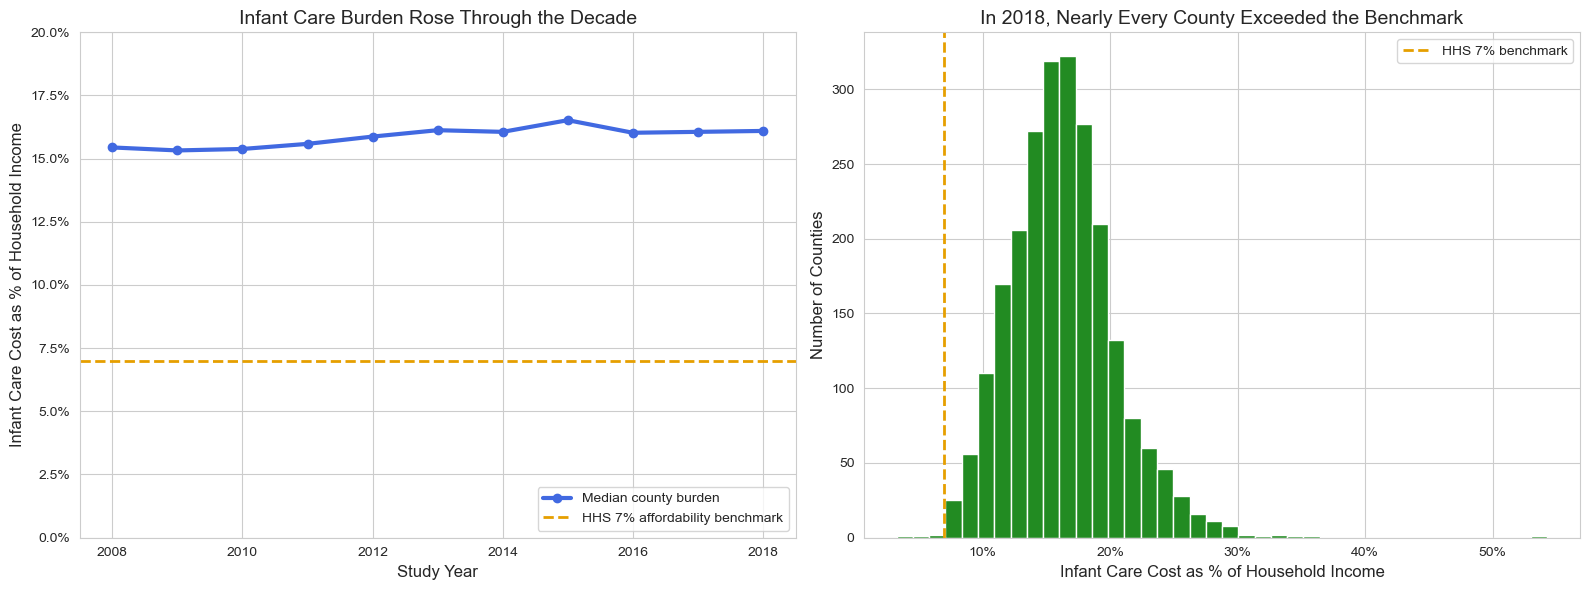

📈 Median burden by year: 15.4% (2008) → 16.1% (2018)
📊 2018 counties below the 7% benchmark: 4 of 2,360


In [7]:
# Build the yearly trend of median income share
trend = afford_df.groupby('year')['income_share'].median()

# Compare decade trend and 2018 distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(trend.index, trend.values, color=ROYAL_BLUE, linewidth=3,
             marker='o', label='Median county burden')
axes[0].axhline(7, color=AMBER, linestyle='--', linewidth=2, label='HHS 7% affordability benchmark')
axes[0].set_title('Infant Care Burden Rose Through the Decade')
axes[0].set_xlabel('Study Year')
axes[0].set_ylabel('Infant Care Cost as % of Household Income')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_ylim(0, 20)
axes[0].legend(loc='lower right')

snapshot_2018 = afford_df[afford_df['year'] == 2018]
axes[1].hist(snapshot_2018['income_share'], bins=40, color=FOREST_GREEN, edgecolor='white')
axes[1].axvline(7, color=AMBER, linestyle='--', linewidth=2, label='HHS 7% benchmark')
axes[1].set_title('In 2018, Nearly Every County Exceeded the Benchmark')
axes[1].set_xlabel('Infant Care Cost as % of Household Income')
axes[1].set_ylabel('Number of Counties')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f'📈 Median burden by year: {trend.loc[2008]:.1f}% (2008) → {trend.loc[2018]:.1f}% (2018)')
print(f'📊 2018 counties below the 7% benchmark: {(snapshot_2018["income_share"] <= 7).sum()} of {len(snapshot_2018):,}')

<div style="page-break-before: always;"></div>

### **Summary**

The National Database of Childcare Prices covers all U.S. counties across 2008–2018, with childcare prices observed for roughly two-thirds of county-years. Three findings emerged.

- Center-based infant care fails the federal 7% affordability benchmark almost universally: in 2018, only 4 of 2,360 reporting counties were affordable, and the median county spent 16.1% of household income on one infant's care.

- The burden grew over the decade even as the economy recovered.

- County-level participation rates of mothers with young children showed no simple relationship with care prices, but the household-level math is stark: one infant consumes 33% of female median earnings in the typical county, and an infant plus a preschooler consumes 61%.

**Key caveats:** prices are nominal and compared against nominal income, roughly a third of price values are missing or imputed (disclosed via flag columns), and female median earnings include part-time workers. These findings support a persuasive story aimed at decision-makers, with the affordability gap as the headline and the second-earner math as the emotional core.

<hr style='border: 2px solid black; border-radius: 2px;'>
    
## **Milestone 1 Paper: The Childcare Affordability Crisis**

### **Summary of Analysis**

The National Database of Childcare Prices (U.S. Department of Labor, Women's Bureau, 2024) contains 34,567 county-year records spanning 2008–2018, covering all U.S. counties across 51 states and the District of Columbia, with 227 columns of childcare prices, labor force measures, earnings, and demographics. The analysis was performed in Python, focusing on median weekly center-based care prices, household income, and female labor force participation.

### **Findings** 

Three findings anchor the story. First, childcare affordability fails almost universally against the federal standard: the U.S. Department of Health and Human Services defines childcare as affordable at no more than 7% of household income, yet 99.7% of county-years exceeded that benchmark. In 2018, only 4 of 2,360 reporting counties were affordable, and the median county spent 16.1% of household income on center-based care for a single infant. Second, the burden grew over the decade, rising from 15.4% of household income in 2008 to 16.1% in 2018, even as the economy recovered. Third, while county-level participation rates of mothers with children under 6 showed no simple correlation with care prices (r = -0.04), the household-level math is stark: one infant in center care consumes 33.2% of female median earnings in the typical county, an infant plus a preschooler consumes 61.1%, and 97.3% of counties exceed one-third of female median earnings for two children. Locally, Bexar County, Texas sits at $8,666 per year for infant care, 33.1% of female median earnings.

### **Assumptions** 

The analysis assumes median center-based prices represent the typical family's cost, full-time care for 52 weeks per year, and that nominal prices should be compared against nominal income within each year. Counties were identified by FIPS code rather than name, since county names repeat across states. Female median earnings include part-time workers, which makes earnings-share figures higher than they would be against full-time salaries; this is disclosed rather than hidden.

### **Items That Still Need Clarification** 

Roughly a third of price values are missing, and reporting coverage grew from 1,424 counties in 2008 to over 2,300 by 2016–2018, so trend statements must acknowledge changing coverage. The dataset's imputation flags identify modeled values, and the extent of imputation in the final visuals needs quantification. Finally, isolating whether high prices cause mothers to exit the workforce would require within-county longitudinal analysis, which is beyond this milestone but worth noting honestly.

### **Direction of Story**

The story is persuasive, not informational: childcare in America — and in Texas — fails the federal government's own affordability standard nearly everywhere, the burden is growing, and the math now forces working mothers to question whether employment pays. The call to action asks Texas legislators to expand state childcare subsidy funding and raise income-eligibility ceilings so that working families above the current cutoff, but far below affordability, are not left out. The message in one line: *when care for two children costs 61% of a mother's median earnings, the workforce problem is a childcare problem.*

### **Target Audience**

The audience is Texas state legislators and their staff. They are unfamiliar with this dataset, policy-literate but not data-literate, so visuals must be simple, jargon-free, and anchored to recognizable benchmarks. My role is a constituent data analyst presenting verified federal data, which provides credibility without institutional affiliation. The audience's likely bias is fiscal skepticism toward new spending, which the story counters by framing childcare as workforce and economic infrastructure rather than welfare, supported by the near-universal failure of the affordability benchmark.

### **Mediums**

Three different mediums will carry the story. A **PowerPoint briefing deck** will walk legislators from the affordability gap through the second-earner math to the specific funding request. A **Power BI dashboard** will let legislative staff look up the childcare burden for the counties in their own districts. A **one-page infographic** will serve as a printed leave-behind and shareable graphic distilling the headline statistics — 4 affordable counties out of 2,360, and 61% of a mother's earnings for two children.

</div>

<div style='border: 5px solid black; padding: 20px; border-radius: 6px;'>

# Reflection for Week 2

## General Reflection
This week built on the foundation from Week 1 by moving from exploratory analysis into shaping a clear, persuasive narrative. The milestone assignment required me to not only analyze the childcare dataset, but also articulate the story, audience, assumptions, and communication plan in a structured paper. Writing the milestone helped me think more intentionally about how data becomes a message, especially when the findings are as extreme as the childcare affordability gap. I also had to balance technical accuracy with accessibility, since the target audience is policy-literate but not data-literate. This pushed me to refine how I explain metrics, trends, and limitations without overwhelming the reader.

## Straightforward Aspects
- Translating the Python analysis into written findings felt natural because the results were consistent and clear across the dataset.
- Summarizing the affordability gap and the second-earner math came easily since both patterns were strong and intuitive.
- Identifying the target audience and their likely concerns helped anchor the direction of the story.
- Outlining the three communication mediums was simple once the narrative structure was defined.

## Challenging Aspects
- Writing the milestone paper required careful wording to keep the tone persuasive without drifting into technical jargon.
- Explaining the limitations, especially the missing data and imputation flags, required nuance so the caveats were honest but not distracting.
- The lack of correlation between childcare prices and maternal labor force participation forced a narrative shift, which required rethinking how to frame the findings.
- Ensuring the story remained relevant to Texas legislators meant tailoring examples and emphasizing local implications, which added an extra layer of consideration.

</div>